# CS-4063 NLP Assignment 3: Transformers + RAG

**Student ID:** i232525  \n
**Dataset:** Amazon Reviews (subset across >=3 categories)

## Execution Instructions
1. Run all cells top-to-bottom.
2. Default config uses a practical subset and moderate epochs for reproducibility.
3. For final grading-quality runs, increase epochs and data size in `CFG`.
4. Outputs are saved in `models/` and `results/`.

This notebook implements: 
- Part A: Encoder-only Transformer (from scratch) for multi-task learning.
- Part B: Embedding retrieval module (top-k cosine similarity).
- Part C: Decoder-only Transformer (from scratch) for explanation generation with and without retrieval (ablation).

## 1) Setup and Configuration
This cell imports libraries, sets seeds, configures device, and defines global hyperparameters in CFG.

In [2]:
import os
import re
import json
import gzip
import math
import time
import random
from dataclasses import dataclass, asdict
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

@dataclass
class CFG:
    data_root: str = './Dataset/Dataset'
    categories: tuple = ('beauty', 'electronics', 'sports')
    samples_per_category: int = 12000

    max_len_encoder: int = 96
    max_len_decoder: int = 128
    min_freq: int = 2

    batch_size: int = 64
    encoder_epochs: int = 5
    decoder_epochs: int = 4
    lr: float = 3e-4
    weight_decay: float = 1e-4

    d_model: int = 192
    n_heads: int = 6
    ff_dim: int = 384
    n_encoder_layers: int = 3
    n_decoder_layers: int = 3
    dropout: float = 0.15

    multitask_alpha: float = 1.0
    multitask_beta: float = 1.0

    retrieval_k: int = 5
    decoder_train_limit: int = 12000

    models_dir: str = './models'
    results_dir: str = './results'

cfg = CFG()
os.makedirs(cfg.models_dir, exist_ok=True)
os.makedirs(cfg.results_dir, exist_ok=True)

print(asdict(cfg))

Device: cpu
{'data_root': './Dataset/Dataset', 'categories': ('beauty', 'electronics', 'sports'), 'samples_per_category': 12000, 'max_len_encoder': 96, 'max_len_decoder': 128, 'min_freq': 2, 'batch_size': 64, 'encoder_epochs': 5, 'decoder_epochs': 4, 'lr': 0.0003, 'weight_decay': 0.0001, 'd_model': 192, 'n_heads': 6, 'ff_dim': 384, 'n_encoder_layers': 3, 'n_decoder_layers': 3, 'dropout': 0.15, 'multitask_alpha': 1.0, 'multitask_beta': 1.0, 'retrieval_k': 5, 'decoder_train_limit': 12000, 'models_dir': './models', 'results_dir': './results'}


## 2) Data Loading and Preprocessing
This cell cleans review text, tokenizes it, maps star ratings to sentiment labels, creates the derived feature, and loads category files.

In [3]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s\'\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text: str):
    return text.split()

def sentiment_from_rating(r):
    r = int(round(float(r)))
    if r <= 2:
        return 0  # negative
    if r == 3:
        return 1  # neutral
    return 2      # positive

def length_bucket(n_tokens):
    if n_tokens <= 20:
        return 0  # short
    if n_tokens <= 60:
        return 1  # medium
    return 2      # long

def read_category(path, limit):
    rows = []
    with gzip.open(path, 'rt', encoding='utf-8') as f:
        for line in f:
            d = json.loads(line)
            txt = d.get('reviewText') or d.get('review_text') or ''
            rating = d.get('overall')
            if rating is None or not txt:
                continue
            txt = clean_text(txt)
            if len(txt) < 5:
                continue
            tokens = tokenize(txt)
            if len(tokens) < 3:
                continue
            rows.append({
                'text': txt,
                'tokens': tokens,
                'rating': int(round(float(rating))),
                'sentiment': sentiment_from_rating(rating),
                'length_bucket': length_bucket(len(tokens)),
            })
            if len(rows) >= limit:
                break
    return rows

all_rows = []
for cat in cfg.categories:
    fp = os.path.join(cfg.data_root, f'{cat}.json.gz')
    rows = read_category(fp, cfg.samples_per_category)
    for r in rows:
        r['category'] = cat
    all_rows.extend(rows)
    print(f'{cat}:', len(rows))

df = pd.DataFrame(all_rows)
print('Total:', len(df))
display(df.head(3))

assert len(df) >= 30000, 'Need at least 30k samples. Increase samples_per_category if required.'

beauty: 12000
electronics: 12000
sports: 12000
Total: 36000


,text,tokens,rating,sentiment,length_bucket,category
0,very oily and creamy not at all what i expecte...,"[very, oily, and, creamy, not, at, all, what, ...",1,0,1,beauty
1,this palette was a decent price and i was look...,"[this, palette, was, a, decent, price, and, i,...",3,1,1,beauty
2,the texture of this concealer pallet is fantas...,"[the, texture, of, this, concealer, pallet, is...",4,2,2,beauty


## 3) Train/Validation/Test Split
This cell performs the required 70/15/15 stratified split and prints class distribution checks.

In [4]:
def stratified_split(df):
    strat_key = df['sentiment'].astype(str) + '_' + df['category'].astype(str)
    train_df, temp_df = train_test_split(
        df, test_size=0.30, random_state=SEED, stratify=strat_key
    )

    strat_temp = temp_df['sentiment'].astype(str) + '_' + temp_df['category'].astype(str)
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, random_state=SEED, stratify=strat_temp
    )

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

train_df, val_df, test_df = stratified_split(df)

print('Train:', len(train_df), 'Val:', len(val_df), 'Test:', len(test_df))
print('Split %:', round(len(train_df)/len(df)*100,2), round(len(val_df)/len(df)*100,2), round(len(test_df)/len(df)*100,2))

for name, sub in [('train',train_df), ('val',val_df), ('test',test_df)]:
    print(name, 'sentiment dist:', sub['sentiment'].value_counts(normalize=True).sort_index().round(3).to_dict())

Train: 25200 Val: 5400 Test: 5400
Split %: 70.0 15.0 15.0
train sentiment dist: {0: 0.094, 1: 0.086, 2: 0.82}
val sentiment dist: {0: 0.094, 1: 0.086, 2: 0.82}
test sentiment dist: {0: 0.094, 1: 0.086, 2: 0.82}


## 4) Vocabulary and Encoder Dataloaders
This cell builds vocabulary from training tokens only, converts tokens to ids, and creates encoder datasets/dataloaders.

In [5]:
PAD, UNK, BOS, EOS, SEP, GEN = '<pad>', '<unk>', '<bos>', '<eos>', '<sep>', '<gen>'
SPECIALS = [PAD, UNK, BOS, EOS, SEP, GEN]

def build_vocab(token_lists, min_freq=2):
    cnt = Counter()
    for toks in token_lists:
        cnt.update(toks)
    vocab = {tok:i for i, tok in enumerate(SPECIALS)}
    for tok, f in cnt.items():
        if f >= min_freq and tok not in vocab:
            vocab[tok] = len(vocab)
    inv_vocab = {i:t for t, i in vocab.items()}
    return vocab, inv_vocab

vocab, inv_vocab = build_vocab(train_df['tokens'], cfg.min_freq)
pad_id = vocab[PAD]
unk_id = vocab[UNK]
bos_id = vocab[BOS]
eos_id = vocab[EOS]
sep_id = vocab[SEP]
gen_id = vocab[GEN]

print('Vocab size:', len(vocab))

def encode_tokens(tokens, vocab, max_len):
    ids = [vocab.get(t, unk_id) for t in tokens[:max_len]]
    attn = [1] * len(ids)
    if len(ids) < max_len:
        pad_n = max_len - len(ids)
        ids += [pad_id] * pad_n
        attn += [0] * pad_n
    return ids, attn

class EncoderDataset(Dataset):
    def __init__(self, frame, vocab, max_len):
        self.frame = frame.reset_index(drop=True)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        ids, mask = encode_tokens(row['tokens'], self.vocab, self.max_len)
        return {
            'input_ids': torch.tensor(ids, dtype=torch.long),
            'attention_mask': torch.tensor(mask, dtype=torch.long),
            'sentiment': torch.tensor(int(row['sentiment']), dtype=torch.long),
            'length_bucket': torch.tensor(int(row['length_bucket']), dtype=torch.long),
            'text': row['text']
        }

train_ds = EncoderDataset(train_df, vocab, cfg.max_len_encoder)
val_ds = EncoderDataset(val_df, vocab, cfg.max_len_encoder)
test_ds = EncoderDataset(test_df, vocab, cfg.max_len_encoder)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False)

Vocab size: 23188


## 5) Encoder Architecture (From Scratch)
This cell defines custom multi-head attention, feed-forward layers, encoder blocks, and the multi-task encoder model.

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None, causal=False):
        B, T, C = x.shape

        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if attention_mask is not None:
            key_mask = attention_mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(key_mask == 0, -1e9)

        if causal:
            cm = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
            scores = scores.masked_fill(cm.unsqueeze(0).unsqueeze(0), -1e9)

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = attn @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)

class FeedForward(nn.Module):
    def __init__(self, d_model, ff_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, ff_dim, dropout)

    def forward(self, x, attention_mask=None):
        x = x + self.attn(self.ln1(x), attention_mask=attention_mask, causal=False)
        x = x + self.ffn(self.ln2(x))
        return x

class EncoderTransformer(nn.Module):
    def __init__(self, vocab_size, max_len, d_model, n_heads, ff_dim, n_layers, dropout):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            EncoderBlock(d_model, n_heads, ff_dim, dropout) for _ in range(n_layers)
        ])

        self.ln_f = nn.LayerNorm(d_model)
        self.sentiment_head = nn.Linear(d_model, 3)
        self.length_head = nn.Linear(d_model, 3)

    def forward(self, input_ids, attention_mask):
        B, T = input_ids.shape
        pos = torch.arange(0, T, device=input_ids.device).unsqueeze(0).expand(B, T)

        x = self.tok_emb(input_ids) + self.pos_emb(pos)
        x = self.drop(x)

        for blk in self.blocks:
            x = blk(x, attention_mask=attention_mask)

        x = self.ln_f(x)

        m = attention_mask.unsqueeze(-1).float()
        pooled = (x * m).sum(dim=1) / m.sum(dim=1).clamp(min=1e-8)

        sent_logits = self.sentiment_head(pooled)
        len_logits = self.length_head(pooled)
        return sent_logits, len_logits, pooled

## 6) Part A Training Loop (Multi-Task)
This cell trains the encoder for sentiment + derived feature prediction, tracks losses/F1, and saves the best checkpoint.

In [7]:
def run_encoder_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    loss_meter = []
    s_true, s_pred = [], []
    l_true, l_pred = [], []

    for b in loader:
        ids = b['input_ids'].to(DEVICE)
        mask = b['attention_mask'].to(DEVICE)
        ys = b['sentiment'].to(DEVICE)
        yl = b['length_bucket'].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            s_logits, l_logits, _ = model(ids, mask)
            loss_s = F.cross_entropy(s_logits, ys)
            loss_l = F.cross_entropy(l_logits, yl)
            loss = cfg.multitask_alpha * loss_s + cfg.multitask_beta * loss_l

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        loss_meter.append(loss.item())
        s_true.extend(ys.cpu().tolist())
        s_pred.extend(s_logits.argmax(-1).detach().cpu().tolist())
        l_true.extend(yl.cpu().tolist())
        l_pred.extend(l_logits.argmax(-1).detach().cpu().tolist())

    return {
        'loss': float(np.mean(loss_meter)),
        'sent_f1': f1_score(s_true, s_pred, average='macro'),
        'len_f1': f1_score(l_true, l_pred, average='macro')
    }

encoder = EncoderTransformer(
    vocab_size=len(vocab),
    max_len=cfg.max_len_encoder,
    d_model=cfg.d_model,
    n_heads=cfg.n_heads,
    ff_dim=cfg.ff_dim,
    n_layers=cfg.n_encoder_layers,
    dropout=cfg.dropout
).to(DEVICE)

opt = torch.optim.AdamW(encoder.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

history_enc = {'train_loss': [], 'val_loss': [], 'train_sent_f1': [], 'val_sent_f1': [], 'train_len_f1': [], 'val_len_f1': []}
best_val = -1

for epoch in range(1, cfg.encoder_epochs + 1):
    t0 = time.time()
    tr = run_encoder_epoch(encoder, train_loader, optimizer=opt)
    va = run_encoder_epoch(encoder, val_loader, optimizer=None)

    history_enc['train_loss'].append(tr['loss'])
    history_enc['val_loss'].append(va['loss'])
    history_enc['train_sent_f1'].append(tr['sent_f1'])
    history_enc['val_sent_f1'].append(va['sent_f1'])
    history_enc['train_len_f1'].append(tr['len_f1'])
    history_enc['val_len_f1'].append(va['len_f1'])

    score = va['sent_f1'] + va['len_f1']
    if score > best_val:
        best_val = score
        torch.save(encoder.state_dict(), os.path.join(cfg.models_dir, 'encoder_best.pt'))

    print(f"Epoch {epoch:02d} | tr_loss={tr['loss']:.4f} va_loss={va['loss']:.4f} | tr_f1=({tr['sent_f1']:.3f},{tr['len_f1']:.3f}) va_f1=({va['sent_f1']:.3f},{va['len_f1']:.3f}) | {time.time()-t0:.1f}s")

encoder.load_state_dict(torch.load(os.path.join(cfg.models_dir, 'encoder_best.pt'), map_location=DEVICE))
print('Best encoder loaded.')

Epoch 01 | tr_loss=0.6546 va_loss=0.5392 | tr_f1=(0.306,0.937) va_f1=(0.312,1.000) | 479.2s
Epoch 02 | tr_loss=0.5133 va_loss=0.5023 | tr_f1=(0.367,1.000) va_f1=(0.438,1.000) | 510.5s
Epoch 03 | tr_loss=0.4777 va_loss=0.4913 | tr_f1=(0.428,1.000) va_f1=(0.422,1.000) | 457.8s
Epoch 04 | tr_loss=0.4434 va_loss=0.4690 | tr_f1=(0.475,1.000) va_f1=(0.476,1.000) | 468.5s
Epoch 05 | tr_loss=0.4118 va_loss=0.4916 | tr_f1=(0.530,1.000) va_f1=(0.468,1.000) | 480.2s
Best encoder loaded.


## 7) Part A Evaluation and Embedding Export
This cell evaluates both tasks on test data, plots learning curves, and saves training embeddings for retrieval.

Part A Test Sentiment Report
              precision    recall  f1-score   support

    negative     0.5216    0.3333    0.4067       507
     neutral     0.3889    0.0756    0.1266       463
    positive     0.8610    0.9691    0.9119      4430

    accuracy                         0.8328      5400
   macro avg     0.5905    0.4593    0.4817      5400
weighted avg     0.7887    0.8328    0.7971      5400

Part A Test Length-Bucket Report
              precision    recall  f1-score   support

       short     1.0000    1.0000    1.0000       249
      medium     1.0000    1.0000    1.0000      2627
        long     1.0000    1.0000    1.0000      2524

    accuracy                         1.0000      5400
   macro avg     1.0000    1.0000    1.0000      5400
weighted avg     1.0000    1.0000    1.0000      5400



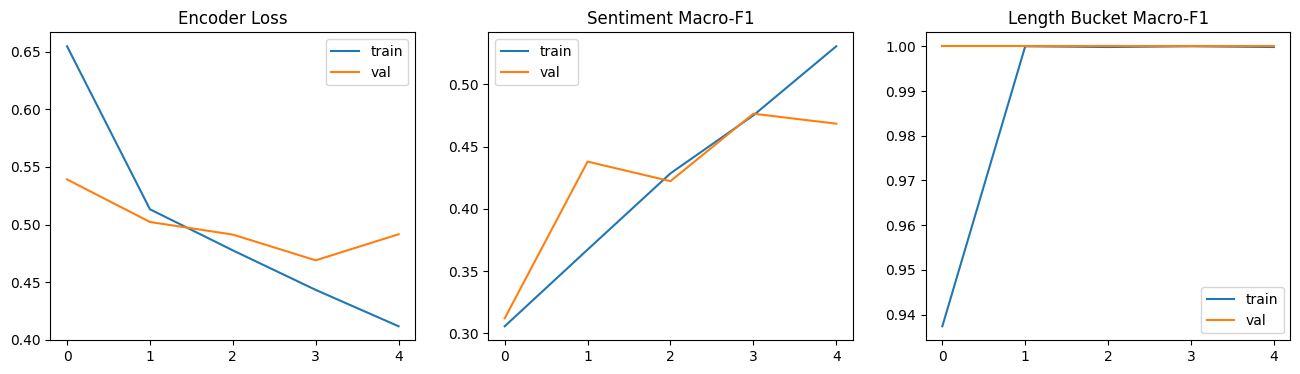

In [ ]:
def collect_encoder_outputs(model, loader):
    model.eval()
    all_emb = []
    s_true, s_pred = [], []
    l_true, l_pred = [], []

    with torch.no_grad():
        for b in loader:
            ids = b['input_ids'].to(DEVICE)
            mask = b['attention_mask'].to(DEVICE)
            ys = b['sentiment'].to(DEVICE)
            yl = b['length_bucket'].to(DEVICE)

            s_logits, l_logits, emb = model(ids, mask)

            all_emb.append(emb.cpu().numpy())
            s_true.extend(ys.cpu().tolist())
            l_true.extend(yl.cpu().tolist())
            s_pred.extend(s_logits.argmax(-1).cpu().tolist())
            l_pred.extend(l_logits.argmax(-1).cpu().tolist())

    out = {
        'embeddings': np.concatenate(all_emb, axis=0),
        'sent_true': np.array(s_true),
        'sent_pred': np.array(s_pred),
        'len_true': np.array(l_true),
        'len_pred': np.array(l_pred),
    }
    return out

enc_train = collect_encoder_outputs(encoder, train_loader)
enc_test = collect_encoder_outputs(encoder, test_loader)

print('Part A Test Sentiment Report')
print(classification_report(enc_test['sent_true'], enc_test['sent_pred'], target_names=['negative','neutral','positive'], digits=4))
print('Part A Test Length-Bucket Report')
print(classification_report(enc_test['len_true'], enc_test['len_pred'], target_names=['short','medium','long'], digits=4))

np.save(os.path.join(cfg.results_dir, 'train_embeddings.npy'), enc_train['embeddings'])
train_df[['text','category','sentiment','length_bucket']].to_csv(os.path.join(cfg.results_dir, 'train_metadata.csv'), index=False)

fig, ax = plt.subplots(1, 3, figsize=(16,4))
ax[0].plot(history_enc['train_loss'], label='train')
ax[0].plot(history_enc['val_loss'], label='val')
ax[0].set_title('Encoder Loss')
ax[0].legend()
ax[1].plot(history_enc['train_sent_f1'], label='train')
ax[1].plot(history_enc['val_sent_f1'], label='val')
ax[1].set_title('Sentiment Macro-F1')
ax[1].legend()
ax[2].plot(history_enc['train_len_f1'], label='train')
ax[2].plot(history_enc['val_len_f1'], label='val')
ax[2].set_title('Length Bucket Macro-F1')
ax[2].legend()
plt.show()

## 8) Part B Retrieval Module
This cell builds the cosine-similarity retrieval index over encoder embeddings and shows top-k qualitative retrieval examples.

In [9]:
class RetrievalIndex:
    def __init__(self, embeddings, texts):
        self.texts = list(texts)
        emb = np.asarray(embeddings).astype(np.float32)
        self.emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)

    def topk(self, query_emb, k=5):
        q = query_emb.astype(np.float32)
        q = q / (np.linalg.norm(q) + 1e-8)
        sims = self.emb @ q
        idx = np.argpartition(-sims, kth=min(k, len(sims)-1)-1)[:k]
        idx = idx[np.argsort(-sims[idx])]
        return [(int(i), float(sims[i]), self.texts[int(i)]) for i in idx]

retrieval_index = RetrievalIndex(enc_train['embeddings'], train_df['text'].tolist())

print('Retrieval qualitative check (3 samples):')
for i in [0, 10, 20]:
    qtxt = test_df.iloc[i]['text']
    qemb = enc_test['embeddings'][i]
    top = retrieval_index.topk(qemb, k=cfg.retrieval_k)
    print('\nQuery:', qtxt[:180])
    for j, (idx, score, t) in enumerate(top, 1):
        print(f'  {j}. score={score:.4f} | {t[:120]}')

Retrieval qualitative check (3 samples):

Query: this is the most unusual moisturizer i have ever tried the texture is very light and it absorbs in almost instantly my new favorite
  1. score=0.9869 | as a woman nearing 50 i need all the help i can get especially as i don't wear foundation this serum goes on silky smoot
  2. score=0.9849 | well i had read all the reviews of this model on amazon and based my purchasing decision partly on this information i ex
  3. score=0.9832 | i love my monster cable since i could not find a 34 computer 34 monster cable i bought the home theater one which seems 
  4. score=0.9832 | works perfectly with both oem glock 22 40 s w magazines and advantage arms 22lr conversion kit magazines secure reliable
  5. score=0.9832 | they work as i expected they would without too much extra material left over and here are my last words

Query: i am very picky about the sharpness of my lenses i own a number of canon lenses including thecanon ef 70-200mm f 4 l is usm

## 9) Part C Input Construction (RAG + Baseline)
This cell builds decoder prompts/targets using review text, predicted labels, and optionally retrieved context for ablation.

In [10]:
SENT2STR = {0:'negative', 1:'neutral', 2:'positive'}
LEN2STR = {0:'short', 1:'medium', 2:'long'}

def build_explanation_target(sent_label, len_label):
    s = SENT2STR[int(sent_label)]
    l = LEN2STR[int(len_label)]
    if s == 'positive':
        return f'The review is {s} because it emphasizes satisfying product experience. The writing is {l}, which provides enough detail to support this judgment.'
    if s == 'negative':
        return f'The review is {s} because it highlights dissatisfaction and product issues. The {l} length adds evidence for a critical assessment.'
    return f'The review is {s} because it mixes favorable and unfavorable cues. Its {l} style reflects a balanced, moderate opinion.'

def truncate_tokens(tokens, n):
    return tokens[:n]

def build_prompt(review_text, sent_pred, len_pred, retrieved_texts=None):
    base = [
        f'review: {review_text}',
        f'predicted_sentiment: {SENT2STR[int(sent_pred)]}',
        f'predicted_length_feature: {LEN2STR[int(len_pred)]}',
    ]
    if retrieved_texts is not None:
        for i, rt in enumerate(retrieved_texts, 1):
            base.append(f'retrieved_{i}: {rt}')
    base.append('generate_explanation:')
    return ' '.join(base)

def prepare_decoder_frame(base_df, enc_out, use_retrieval=True, limit=None):
    n = len(base_df) if limit is None else min(limit, len(base_df))
    rows = []
    for i in range(n):
        row = base_df.iloc[i]
        sp = int(enc_out['sent_pred'][i])
        lp = int(enc_out['len_pred'][i])

        retrieved = None
        if use_retrieval:
            top = retrieval_index.topk(enc_out['embeddings'][i], k=cfg.retrieval_k)
            retrieved = [t for _, _, t in top]

        prompt = build_prompt(row['text'], sp, lp, retrieved_texts=retrieved)
        target = build_explanation_target(sp, lp)

        rows.append({'prompt': prompt, 'target': target})

    return pd.DataFrame(rows)

enc_val = collect_encoder_outputs(encoder, val_loader)

train_dec_rag = prepare_decoder_frame(train_df, enc_train, use_retrieval=True, limit=cfg.decoder_train_limit)
val_dec_rag = prepare_decoder_frame(val_df, enc_val, use_retrieval=True, limit=3000)
test_dec_rag = prepare_decoder_frame(test_df, enc_test, use_retrieval=True, limit=3000)

train_dec_base = prepare_decoder_frame(train_df, enc_train, use_retrieval=False, limit=cfg.decoder_train_limit)
val_dec_base = prepare_decoder_frame(val_df, enc_val, use_retrieval=False, limit=3000)
test_dec_base = prepare_decoder_frame(test_df, enc_test, use_retrieval=False, limit=3000)

display(train_dec_rag.head(2))

,prompt,target
0,review: this is a cable it allows power to be ...,The review is positive because it emphasizes s...
1,review: i needed a couple of beds to lay side ...,The review is positive because it emphasizes s...


## 10) Decoder Dataset and Decoder-Only Transformer
This cell prepares language-modeling inputs and defines the causal decoder architecture from scratch.

In [11]:
def text_to_ids(text, vocab, max_len):
    toks = tokenize(clean_text(text))
    ids = [vocab.get(t, unk_id) for t in toks]
    ids = ids[:max_len]
    return ids

class DecoderDataset(Dataset):
    def __init__(self, frame, vocab, max_len):
        self.frame = frame.reset_index(drop=True)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]

        prompt_ids = text_to_ids(row['prompt'], self.vocab, self.max_len // 2)
        target_ids = text_to_ids(row['target'], self.vocab, self.max_len // 2)

        seq = [bos_id] + prompt_ids + [gen_id] + target_ids + [eos_id]
        seq = seq[:self.max_len]

        labels = seq[1:] + [pad_id]

        # Loss is applied only after <gen> token to focus LM objective on explanation generation.
        gen_pos = seq.index(gen_id) if gen_id in seq else len(seq)-1
        loss_mask = [0] * (gen_pos + 1) + [1] * (len(seq) - gen_pos - 1)
        loss_mask = loss_mask[:len(seq)]

        if len(seq) < self.max_len:
            pad_n = self.max_len - len(seq)
            seq += [pad_id] * pad_n
            labels += [pad_id] * pad_n
            loss_mask += [0] * pad_n

        return {
            'input_ids': torch.tensor(seq, dtype=torch.long),
            'labels': torch.tensor(labels, dtype=torch.long),
            'attention_mask': torch.tensor([1 if t != pad_id else 0 for t in seq], dtype=torch.long),
            'loss_mask': torch.tensor(loss_mask, dtype=torch.float32),
            'prompt': row['prompt'],
            'target': row['target']
        }

class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, ff_dim, dropout)

    def forward(self, x, attention_mask=None):
        x = x + self.attn(self.ln1(x), attention_mask=attention_mask, causal=True)
        x = x + self.ffn(self.ln2(x))
        return x

class DecoderTransformerLM(nn.Module):
    def __init__(self, vocab_size, max_len, d_model, n_heads, ff_dim, n_layers, dropout):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            DecoderBlock(d_model, n_heads, ff_dim, dropout) for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, input_ids, attention_mask):
        B, T = input_ids.shape
        pos = torch.arange(0, T, device=input_ids.device).unsqueeze(0).expand(B, T)
        x = self.tok_emb(input_ids) + self.pos_emb(pos)
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x, attention_mask=attention_mask)
        x = self.ln_f(x)
        logits = self.head(x)
        return logits

def lm_loss(logits, labels, loss_mask):
    B, T, V = logits.shape
    flat_loss = F.cross_entropy(logits.view(B*T, V), labels.view(-1), reduction='none')
    flat_loss = flat_loss.view(B, T)
    masked = (flat_loss * loss_mask).sum() / loss_mask.sum().clamp(min=1.0)
    return masked

## 11) Decoder Training (RAG and No-Retrieval Baseline)
This cell trains two decoder variants for ablation: full RAG context and baseline without retrieved reviews.

In [12]:
def train_decoder(train_frame, val_frame, model_name):
    train_ds_dec = DecoderDataset(train_frame, vocab, cfg.max_len_decoder)
    val_ds_dec = DecoderDataset(val_frame, vocab, cfg.max_len_decoder)

    train_ld = DataLoader(train_ds_dec, batch_size=cfg.batch_size, shuffle=True)
    val_ld = DataLoader(val_ds_dec, batch_size=cfg.batch_size, shuffle=False)

    model = DecoderTransformerLM(
        vocab_size=len(vocab),
        max_len=cfg.max_len_decoder,
        d_model=cfg.d_model,
        n_heads=cfg.n_heads,
        ff_dim=cfg.ff_dim,
        n_layers=cfg.n_decoder_layers,
        dropout=cfg.dropout
    ).to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    hist = {'train_loss': [], 'val_loss': []}
    best = 1e9

    for ep in range(1, cfg.decoder_epochs + 1):
        model.train()
        tr_losses = []
        for b in train_ld:
            ids = b['input_ids'].to(DEVICE)
            am = b['attention_mask'].to(DEVICE)
            labels = b['labels'].to(DEVICE)
            lm = b['loss_mask'].to(DEVICE)

            logits = model(ids, am)
            loss = lm_loss(logits, labels, lm)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_losses.append(loss.item())

        model.eval()
        va_losses = []
        with torch.no_grad():
            for b in val_ld:
                ids = b['input_ids'].to(DEVICE)
                am = b['attention_mask'].to(DEVICE)
                labels = b['labels'].to(DEVICE)
                lm = b['loss_mask'].to(DEVICE)
                logits = model(ids, am)
                loss = lm_loss(logits, labels, lm)
                va_losses.append(loss.item())

        tr_loss = float(np.mean(tr_losses))
        va_loss = float(np.mean(va_losses))
        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(va_loss)

        if va_loss < best:
            best = va_loss
            torch.save(model.state_dict(), os.path.join(cfg.models_dir, model_name))

        print(f'[{model_name}] epoch {ep:02d} train={tr_loss:.4f} val={va_loss:.4f}')

    model.load_state_dict(torch.load(os.path.join(cfg.models_dir, model_name), map_location=DEVICE))
    return model, hist

decoder_rag, hist_rag = train_decoder(train_dec_rag, val_dec_rag, 'decoder_rag_best.pt')
decoder_base, hist_base = train_decoder(train_dec_base, val_dec_base, 'decoder_noretrieval_best.pt')

[decoder_rag_best.pt] epoch 01 train=1.6681 val=0.0707
[decoder_rag_best.pt] epoch 02 train=0.0617 val=0.0388
[decoder_rag_best.pt] epoch 03 train=0.0390 val=0.0262
[decoder_rag_best.pt] epoch 04 train=0.0327 val=0.0235
[decoder_noretrieval_best.pt] epoch 01 train=1.9283 val=0.0832
[decoder_noretrieval_best.pt] epoch 02 train=0.0674 val=0.0373
[decoder_noretrieval_best.pt] epoch 03 train=0.0402 val=0.0253
[decoder_noretrieval_best.pt] epoch 04 train=0.0324 val=0.0248


## 12) Perplexity Evaluation and Autoregressive Generation
This cell computes test perplexity for both models and defines token-by-token explanation generation.

RAG Decoder Test NLL=0.0217, PPL=1.022
Baseline Decoder Test NLL=0.0235, PPL=1.024


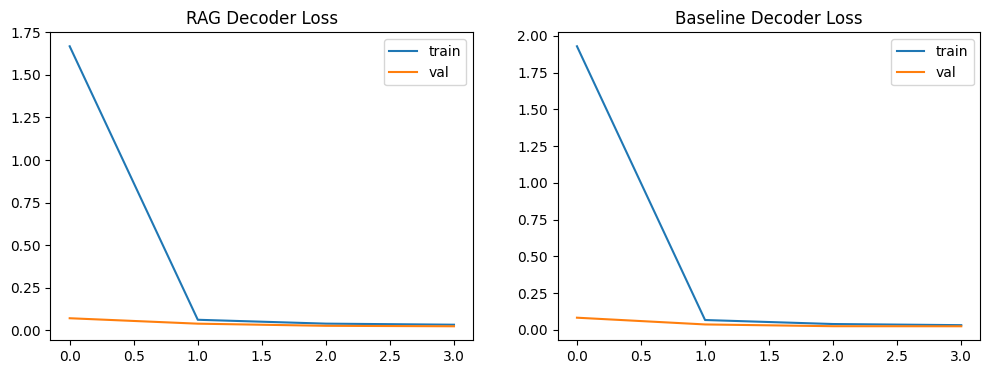

In [13]:
def evaluate_perplexity(model, frame):
    ds = DecoderDataset(frame, vocab, cfg.max_len_decoder)
    ld = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False)
    model.eval()
    losses = []
    with torch.no_grad():
        for b in ld:
            ids = b['input_ids'].to(DEVICE)
            am = b['attention_mask'].to(DEVICE)
            labels = b['labels'].to(DEVICE)
            lm = b['loss_mask'].to(DEVICE)
            logits = model(ids, am)
            losses.append(lm_loss(logits, labels, lm).item())
    m = float(np.mean(losses))
    return m, float(math.exp(m))

def decode_ids(ids):
    toks = [inv_vocab.get(i, UNK) for i in ids]
    toks = [t for t in toks if t not in (PAD, BOS)]
    out = []
    for t in toks:
        if t == EOS:
            break
        out.append(t)
    return ' '.join(out).strip()

def generate_explanation(model, prompt_text, max_new_tokens=40):
    model.eval()
    prompt_ids = [bos_id] + text_to_ids(prompt_text, vocab, cfg.max_len_decoder-2) + [gen_id]
    x = torch.tensor(prompt_ids, dtype=torch.long, device=DEVICE).unsqueeze(0)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            if x.size(1) >= cfg.max_len_decoder:
                break
            am = torch.ones_like(x, dtype=torch.long, device=DEVICE)
            logits = model(x, am)
            nxt = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
            x = torch.cat([x, nxt], dim=1)
            if int(nxt.item()) == eos_id:
                break

    full = x.squeeze(0).tolist()
    if gen_id in full:
        gen_part = full[full.index(gen_id)+1:]
    else:
        gen_part = full
    return decode_ids(gen_part)

rag_nll, rag_ppl = evaluate_perplexity(decoder_rag, test_dec_rag)
base_nll, base_ppl = evaluate_perplexity(decoder_base, test_dec_base)

print(f'RAG Decoder Test NLL={rag_nll:.4f}, PPL={rag_ppl:.3f}')
print(f'Baseline Decoder Test NLL={base_nll:.4f}, PPL={base_ppl:.3f}')

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(hist_rag['train_loss'], label='train')
ax[0].plot(hist_rag['val_loss'], label='val')
ax[0].set_title('RAG Decoder Loss')
ax[0].legend()
ax[1].plot(hist_base['train_loss'], label='train')
ax[1].plot(hist_base['val_loss'], label='val')
ax[1].set_title('Baseline Decoder Loss')
ax[1].legend()
plt.show()

## 13) Qualitative Examples and Final Artifact Saving
This cell generates sample explanations, logs ablation metrics, and saves all final outputs for submission/reporting.

In [14]:
qual_rows = []
for i in range(5):
    pr_rag = test_dec_rag.iloc[i]['prompt']
    pr_base = test_dec_base.iloc[i]['prompt']

    gen_rag = generate_explanation(decoder_rag, pr_rag)
    gen_base = generate_explanation(decoder_base, pr_base)

    qual_rows.append({
        'example_id': i,
        'reference': test_dec_rag.iloc[i]['target'],
        'generated_rag': gen_rag,
        'generated_baseline': gen_base
    })

qual_df = pd.DataFrame(qual_rows)
display(qual_df)

metrics = {
    'encoder': {
        'sentiment_macro_f1': float(f1_score(enc_test['sent_true'], enc_test['sent_pred'], average='macro')),
        'length_macro_f1': float(f1_score(enc_test['len_true'], enc_test['len_pred'], average='macro'))
    },
    'retrieval': {
        'k': cfg.retrieval_k,
        'similarity': 'cosine'
    },
    'decoder': {
        'rag_test_ppl': rag_ppl,
        'baseline_test_ppl': base_ppl
    },
    'ablation': {
        'ppl_gain_baseline_minus_rag': base_ppl - rag_ppl
    },
    'hyperparams': asdict(cfg)
}

with open(os.path.join(cfg.results_dir, 'metrics_summary.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

qual_df.to_csv(os.path.join(cfg.results_dir, 'qualitative_examples.csv'), index=False)

print('Saved:')
print('-', os.path.join(cfg.models_dir, 'encoder_best.pt'))
print('-', os.path.join(cfg.models_dir, 'decoder_rag_best.pt'))
print('-', os.path.join(cfg.models_dir, 'decoder_noretrieval_best.pt'))
print('-', os.path.join(cfg.results_dir, 'train_embeddings.npy'))
print('-', os.path.join(cfg.results_dir, 'train_metadata.csv'))
print('-', os.path.join(cfg.results_dir, 'metrics_summary.json'))
print('-', os.path.join(cfg.results_dir, 'qualitative_examples.csv'))

,example_id,reference,generated_rag,generated_baseline
0,0,The review is positive because it emphasizes s...,,review is positive because it emphasizes satis...
1,1,The review is negative because it highlights d...,,review is negative because it highlights <unk>...
2,2,The review is positive because it emphasizes s...,,review is positive because it emphasizes satis...
3,3,The review is positive because it emphasizes s...,,
4,4,The review is negative because it highlights d...,,


Saved:
- ./models\encoder_best.pt
- ./models\decoder_rag_best.pt
- ./models\decoder_noretrieval_best.pt
- ./results\train_embeddings.npy
- ./results\train_metadata.csv
- ./results\metrics_summary.json
- ./results\qualitative_examples.csv


## Report Notes Checklist
- Preprocessing pipeline: cleaning, tokenization, train-only vocabulary, truncation/padding.
- Part A: architecture, combined loss, learning curves, test metrics for both tasks.
- Part B: retrieval examples, quality analysis, similarity metric discussion, effect of k.
- Part C: input template, causal masking, perplexity, 5 qualitative examples.
- Ablation: compare RAG vs no-retrieval perplexity and sample quality.
- Hyperparameter exploration: modify `CFG` and log outcomes in report.